# Simulate Populations with Spontaneus Birth
## Part 8

So far we have learned that we can multiply $Prob.(T \leq t)$ with the population equilibrium $P=\frac{B}{d}$ to obtain the expected population at $t$ when the starting population $P=0$.

However, we can do better. We have all the pieces to find $f(P_{t=0},\ t)$ so that we can calculate the population at time step $t$ given _any_ starting population. Let's see how it's done.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def survive_exactly(death_chance, t):
    """ Probability of surviving exactly to time step p given a constant 
        death_chance independent at each step."""
    if not isinstance(t, int):
        raise TypeError
    else:
        return (1-death_chance)**(t-1)*death_chance if t > 0 else 0

def series_pleqt(n_periods, death_chance):
    """Calculate P(T<=t) for n periods"""
    pleqt_series = pd.Series(
        [
            sum(survive_exactly(death_chance, t)
            for t in range(0,i+1)) #range(0, 0) creates an empty list
            for i in range(0, n_periods+1)
        ],
        name="Prob(T<=t)",
        # index=(f"t={t:02}" for t in range(0, n_periods+1))
        )
    return pleqt_series

def pop_equilib(birth_rate, death_chance):
    """ Calculate the population equilibrium for population with constant birth rate
        and independent death chance"""

    return birth_rate/death_chance

In [3]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
n_periods = 25

### Calculate Population with $f(P_{t=0},\ t)$

When the population at $P_{t=0}\geq$ 0, we can determine the difference between the population equilibrium and $P_{t=0}$ with $\frac{B}{d}-P_{t=0}$. Multiplying this with $Prob.(T \leq t)$ will then give us the population growth curve from $P_{t=0}$ to $\frac{B}{d}$. However, this curve will be offset along the y-axis by $P_{t=0}$, so we need to add it back to the result. This then gives us the following function.

$$
\begin{equation*}
\begin{aligned}
f(P_{t=0},\ t) &=  P_{t=0}+Prob.(T \leq t)\left(\frac{B}{d}-P_{t=0}\right) \\
&= P_{t=0}+\left(\sum_{t=1}^n (1-d)^{t-1}d\right)\left(\frac{B}{d}-P_{t=0}\right)
\end{aligned}
\end{equation*}
$$



In [4]:
def series_population(birth_rate, death_chance, starting_pop, n_periods):
    """ Calculate population at t for population with constant birth rate
        and independent death chance"""
        
    series = starting_pop + series_pleqt(n_periods, death_chance)*(pop_equilib(birth_rate, death_chance) - starting_pop)
    series.name = "Population (t)"
    return series

### Assessing the result of $f(P_{t=0},\ t)$ against it's recursive counterpart from part 6

Let's confirm the function we found is correct by printing out the population from $t=0$ to $t=25$ for various starting populations.

In [5]:
def generate_table(function, birth_rate, death_rate, n_rows, n_cols, col_tag="col"):
    """ Generate a table with rows from 0 to n_rows and columns from 0 to n_cols
        where function(birth_rate, death_chance, starting_pop=col, n_periods=n_rows 
        is applied to each column"""

    df = pd.DataFrame()
    for col in range(n_cols):
        col_name = f"{col_tag}_{col}"
        df[col_name] = function(birth_rate, death_chance, col, n_rows)
    return df

df = generate_table(series_population, birth_rate, death_chance, 25, 20, "Pop")
df

,Pop_0,Pop_1,Pop_2,Pop_3,Pop_4,Pop_5,Pop_6,Pop_7,Pop_8,Pop_9,Pop_10,Pop_11,Pop_12,Pop_13,Pop_14,Pop_15,Pop_16,Pop_17,Pop_18,Pop_19
0,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.0,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000,17.000000,18.000000,19.000000
1,1.000000,1.900000,2.800000,3.700000,4.600000,5.500000,6.400000,7.300000,8.200000,9.100000,10.0,10.900000,11.800000,12.700000,13.600000,14.500000,15.400000,16.300000,17.200000,18.100000
2,1.900000,2.710000,3.520000,4.330000,5.140000,5.950000,6.760000,7.570000,8.380000,9.190000,10.0,10.810000,11.620000,12.430000,13.240000,14.050000,14.860000,15.670000,16.480000,17.290000
3,2.710000,3.439000,4.168000,4.897000,5.626000,6.355000,7.084000,7.813000,8.542000,9.271000,10.0,10.729000,11.458000,12.187000,12.916000,13.645000,14.374000,15.103000,15.832000,16.561000
4,3.439000,4.095100,4.751200,5.407300,6.063400,6.719500,7.375600,8.031700,8.687800,9.343900,10.0,10.656100,11.312200,11.968300,12.624400,13.280500,13.936600,14.592700,15.248800,15.904900
5,4.095100,4.685590,5.276080,5.866570,6.457060,7.047550,7.638040,8.228530,8.819020,9.409510,10.0,10.590490,11.180980,11.771470,12.361960,12.952450,13.542940,14.133430,14.723920,15.314410
6,4.685590,5.217031,5.748472,6.279913,6.811354,7.342795,7.874236,8.405677,8.937118,9.468559,10.0,10.531441,11.062882,11.594323,12.125764,12.657205,13.188646,13.720087,14.251528,14.782969
7,5.217031,5.695328,6.173625,6.651922,7.130219,7.608516,8.086812,8.565109,9.043406,9.521703,10.0,10.478297,10.956594,11.434891,11.913188,12.391485,12.869781,13.348078,13.826375,14.304672
8,5.695328,6.125795,6.556262,6.986730,7.417197,7.847664,8.278131,8.708598,9.139066,9.569533,10.0,10.430467,10.860934,11.291402,11.721869,12.152336,12.582803,13.013270,13.443738,13.874205
9,6.125795,6.513216,6.900636,7.288057,7.675477,8.062898,8.450318,8.837739,9.225159,9.612580,10.0,10.387420,10.774841,11.162261,11.549682,11.937102,12.324523,12.711943,13.099364,13.486784




As you can see, when the starting population is below the equilibrium of 10, the population grows towards 10. However, when population is above the equilibrium of 10 population shrinks towards 10. When starting populatin is 10, it never changes. We observed the same pattern in part 6 of this notebook series, where we used a recursive function to find popualtion. When comparing these values to those shown in the table generated during part 3, you will see they are identical.

### Assessing the result of $f(P_{t=0},\ t)$ against the simulation from part 2

In [66]:
import random

def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance, starting_pop):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = [entity() for p in range(0, starting_pop)]
        self.history = [starting_pop]

    def __call__(self):
        self.population = [e() for e in self.population if not trial(self.death_chance)]
        self.population = self.population + (self.birth_rate * [entity()])
        self.history.append(len(self.population))

In [67]:
[entity()()] + (2 * [entity()])

[1, 0, 0]

In [68]:
env = environment(2, .1, 0)

In [73]:
env()
env.population

[6, 6, 6, 4, 4, 1, 0, 0]

In [80]:
def run_sim(birth_rate, death_chance, starting_pop, n_periods, r_runs):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(-1, n_periods),
    )

    # Run numerical model (simulation simplified by recursive function) 
    p_function = series_population(birth_rate, death_chance, starting_pop, n_periods)

    # Run simulation n times with r repeats.
    for r in range(r_runs):
        env = environment(birth_rate, death_chance, starting_pop)
        for period in range(0, n_periods+1):
            env()
        ax.plot(env.history, color=[.5, .5, .5, .5])
        ax.plot(range(0, n_periods+1), p_function, color='k')

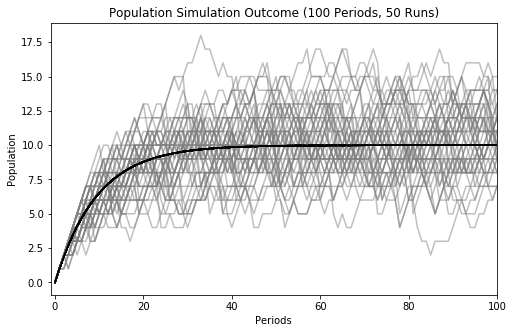

In [91]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

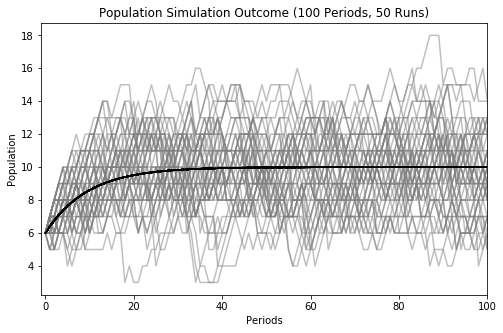

In [92]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
starting_pop = 6

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

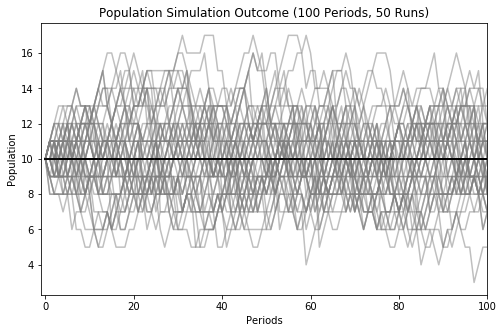

In [93]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
starting_pop = 10

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

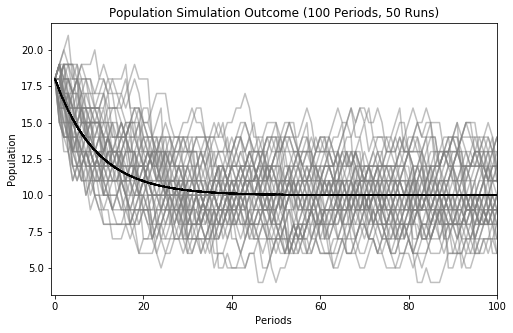

In [94]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
starting_pop = 18

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

Let's vary the death chance and see how the simulation and modeling function respond.

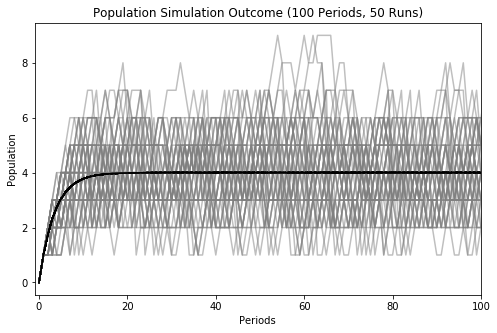

In [99]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.25
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

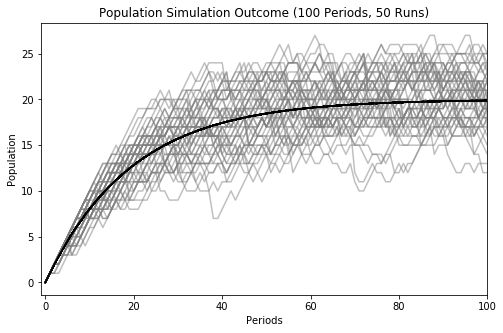

In [100]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.05
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

Let's also vary the `birth_rate` and see how the model responds.

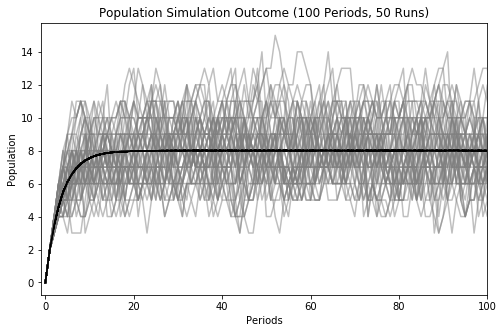

In [104]:
# Set simulation parameters
birth_rate = 2
death_chance = 0.25
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

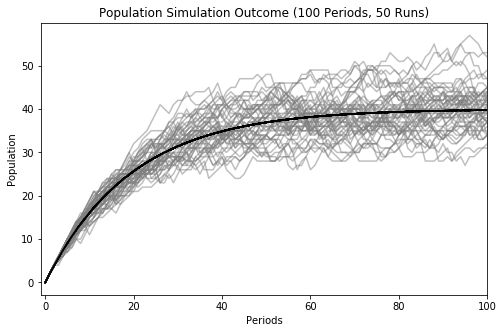

In [105]:
# Set simulation parameters
birth_rate = 2
death_chance = 0.05
starting_pop = 0

# Run the simulation
run_sim(birth_rate, death_chance, starting_pop, 100, 50)

### Conclusion

As you can see, the function tracks the average of the simulated population perfectly, even when varying `starting_population`, `birth_rate`, and `death_chance`.